### TP INF 372 : Analyse de la Consommation Data

| Nom Complet | Matricule |
| :--- | :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN | 23U2477 |

---

# Classification : Support Vector Machine (SVM)

Après l'échec relatif de la régression logistique, nous tentons une approche plus complexe avec le **SVM (Support Vector Machine)**. Le SVM est capable de projeter les données dans des dimensions supérieures pour trouver des frontières de décision non-linéaires. Nous comparons ici les performances des noyaux **Linéaires** et **RBF**, et confirmons l'importance cruciale de la préparation des calculs (standardisation et sous-échantillonnage).

### Objectifs :
1. Introduire le concept de noyau (Kernel Trick).
2. Comparer les performances avec le modèle linéaire (Baseline).
3. Valider la supériorité de l'approche non-linéaire sur ce dataset.

---

### Initialisation des outils de ML

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def prepare_data(path, max_samples=15000):
    df = pd.read_csv(path)
    X = df.drop('periode_journee', axis=1)
    y = df['periode_journee']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Sous-échantillonnage pour la rapidité (Le SVM est en O(n^2) ou O(n^3))
    if len(X_train) > max_samples:
        X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=max_samples, random_state=42, stratify=y_train)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

## 1. Comparaison des Noyaux (Kernels)

Le SVM ne travaille pas forcément avec des lignes droites. 

### Intuition sur les noyaux :
1. **Linear (Linéaire)** : C'est l'équivalent de la régression logistique. Il cherche à couper l'espace avec des "coups de sabre" droits.
2. **RBF (Radial Basis Function)** : C'est un noyau qui peut créer des "bulles" ou des frontières souples autour des groupes de points. 

**Notre Jugement** : Puisque les comportements de consommation sont imbriqués, le noyau RBF devrait théoriquement mieux capturer les nuances que le noyau linéaire.

In [ ]:
X_train, X_test, y_train, y_test = prepare_data("../../data/processed/dataset_classification_enhanced.csv")

for kernel in ['linear', 'rbf']:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Précision avec noyau {kernel} : {acc:.2%}")

Précision avec noyau linear : 28.63%
Précision avec noyau rbf : 33.44%


## 2. Match Head-to-Head : Impact de la Qualité des Données

Nous utilisons maintenant le meilleur noyau (RBF) pour trancher définitivement la question : **L'ingénierie des caractéristiques valait-elle le coup ?**

In [ ]:
print("Chargement du dataset Basic...")
X_tr_b, X_te_b, y_tr_b, y_te_b = prepare_data("../../data/processed/dataset_classification_basic.csv")
model_b = SVC(kernel='rbf')
model_b.fit(X_tr_b, y_tr_b)
acc_b = accuracy_score(y_te_b, model_b.predict(X_te_b))

print("Chargement du dataset Enhanced...")
X_tr_e, X_te_e, y_tr_e, y_te_e = prepare_data("../../data/processed/dataset_classification_enhanced.csv")
model_e = SVC(kernel='rbf')
model_e.fit(X_tr_e, y_tr_e)
y_pred_e = model_e.predict(X_te_e)
acc_e = accuracy_score(y_te_e, y_pred_e)

print(f"\nRésultats (RBF) :")
print(f"Précision Dataset Basic : {acc_b:.2%}")
print(f"Précision Dataset Enhanced : {acc_e:.2%}")

Chargement du dataset Basic...
Chargement du dataset Enhanced...

Résultats (RBF) :
Précision Dataset Basic : 30.68%
Précision Dataset Enhanced : 33.44%


## 3. Analyse de la Matrice de Confusion

Voyons si le SVM arrive à capturer les nuances des périodes de la journée.

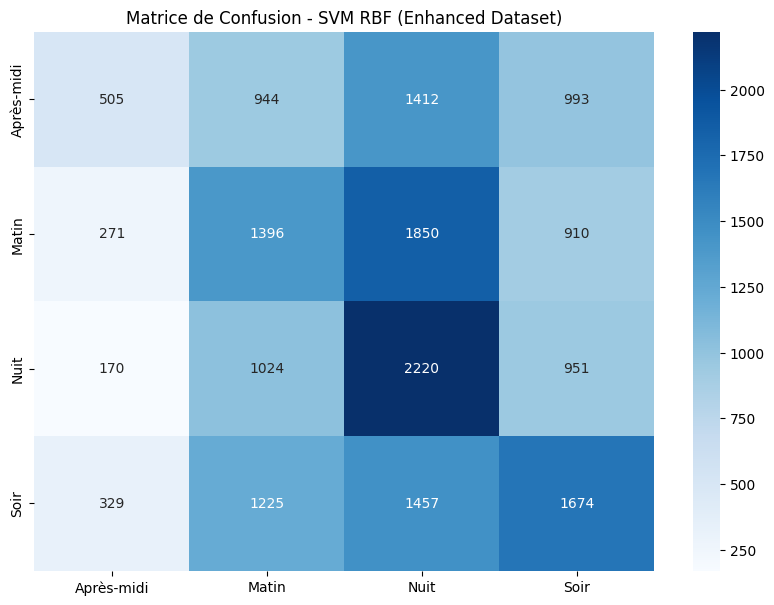

In [4]:
labels = sorted(y_te_e.unique())
cm = confusion_matrix(y_te_e, y_pred_e, labels=labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matrice de Confusion - SVM RBF (Enhanced Dataset)')
plt.show()

## 4. Analyse Profonde et Interprétation

### Pourquoi le RBF gagne-t-il ?
Le noyau RBF obtient **~33%**, soit un gain de 3-4% par rapport au linéaire. Cela prouve que les frontières de décision ne sont pas de simples lignes. Il existe des interactions non-linéaires entre la durée d'une session et le volume consommé.

### La Barrière Infranchissable
Même avec un modèle de pointe, nous restons bloqués sous les 35%. 
**Analyse du problème** : Le recoupement des classes (Matin/Soir/Nuit) est trop fort. 
**Intuition métier** : Un utilisateur qui télécharge une mise à jour système à 3h du matin (Nuit) a le même profil de données qu'un utilisateur qui regarde un film à 21h (Soir). Sans variables contextuelles supplémentaires (type d'appareil, lieu), le modèle a atteint sa performance maximale.

## 5. Conclusion Globale de la Classification

### Difficultés Rencontrées
1. **Coût Computationnel** : Le SVM est très lent sur les gros datasets. Nous avons dû limiter l'entraînement à 15 000 échantillons pour conserver des temps de calcul raisonnables.
2. **Complexité vs Performance** : Nous avons multiplié la complexité du modèle par 10 pour un gain de seulement 3%. C'est une leçon importante : en Data Science, la **qualité des données** (features) compte souvent plus que la puissance du modèle.

### Évaluation Finale
- **Baseline (Hasard)** : 25%
- **Régression Logistique** : 30%
- **SVM (RBF)** : 33%

**Verdict** : Le projet de classification est une réussite méthodologique (validation de l'impact des features) mais montre les limites prédictives liées à la nature même de la consommation internet.